### Práctica: Algoritmos de intersección y unión de conjuntos en el modelo de comparación
### Nombre Alumno : Isaac Hernandez Ramirez

## Introducción
La operación de intersección de conjuntos ordenados es fundamental en sistemas de recuperación de información, bases de datos y procesamiento de textos, ya que permite hallar eficientemente elementos comunes en colecciones de datos. Tradicionalmente, los métodos más sencillos, como el algoritmo de “merge” de Bentley y Yao, escanean simultáneamente dos listas en tiempo lineal en la suma de sus tamaños [Bentley & Yao, 1976]. Sin embargo, al escalar a múltiples listas y a conjuntos de tamaños muy distintos, surgen variantes más adaptativas y eficientes.

En 2004, Baeza-Yates propuso un algoritmo de intersección para secuencias ordenadas que explota búsquedas binarias para reducir el número de comparaciones en escenarios desequilibrados [Baeza-Yates, 2004]. Paralelamente, Demaine et al. investigaron enfoques adaptativos que seleccionan dinámicamente la estrategia de búsqueda según la distribución de los datos [Demaine et al., 2001]. Inspirados por estas ideas, Barbay y Kenyon desarrollaron en 2002 un método adaptable basado en umbrales t-threshold, combinando saltos exponenciales y búsqueda binaria para manejar múltiples listas de manera más equilibrada [Barbay & Kenyon, 2002].

Más recientemente, extensiones de estos trabajos han explorado implementaciones prácticas y mejoras experimentales. En particular, Barbay, López-Ortiz y Lu (2006) reportaron optimizaciones que aceleran las intersecciones adaptativas para búsqueda de texto, mientras que Pugh (1990) introdujo las “skip lists” como una alternativa probabilística que facilita saltos rápidos en estructuras enlazadas. Este reporte implementa y compara tres familias de algoritmos—Melding (ME), Baeza-Yates (BY) con variantes de búsqueda y Barbay & Kenyon (BK)—siguiendo la teoría de los capítulos 5 y 6 del texto proporcionado, con el fin de evaluar su rendimiento en conjuntos de diferentes tamaños y cardinalidades.

# Análisis de Algoritmos de Intersección de Conjuntos

Este cuaderno implementa y analiza múltiples algoritmos de intersección de conjuntos:
- Melding (ME)
- Baeza-Yates (BY) con diferentes métodos de búsqueda (bisección, B1, B2)
- Barbay & Kenyon (BK)

Compararemos su rendimiento en diferentes conjuntos de datos en términos de tiempo de ejecución, número de comparaciones y longitud de las intersecciones.

In [2]:
# Importar bibliotecas requeridas
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from typing import List, Set, Dict, Tuple, Any, Union, Optional
import os
import json
import time

## Carga y Preparación de Datos

Primero, cargaremos los archivos JSON que contienen nuestros conjuntos de datos:
- Conjunto de datos A: Contiene pares de conjuntos
- Conjunto de datos B: Contiene tripletas de conjuntos
- Conjunto de datos C: Contiene tetrapletas (conjuntos de 4)

Analizaremos estos archivos y organizaremos los datos en estructuras apropiadas para nuestros algoritmos de intersección.

In [3]:
# Definir rutas de archivos - actualizar a las ubicaciones reales de los archivos
data_dir = os.path.join(os.getcwd())
print(f"Directorio de datos: {data_dir}")
dataset_a_path = os.path.join(data_dir, "posting\postinglists-for-intersection-A-k=2.json")
dataset_b_path = os.path.join(data_dir, "posting\postinglists-for-intersection-B-k=3.json")
dataset_c_path = os.path.join(data_dir, "posting\postinglists-for-intersection-C-k=4.json")

# Función para cargar datos JSON
def load_json_data(file_path):
    try:
        with open(file_path, 'r') as file:
            return json.load(file)
    except FileNotFoundError:
        print(f"Advertencia: Archivo {file_path} no encontrado.")

# Cargar conjuntos de datos
dataset_a = load_json_data(dataset_a_path)  # Pares
dataset_b = load_json_data(dataset_b_path)  # Tripletas
dataset_c = load_json_data(dataset_c_path)  # Tetrapletas

print(f"Conjunto de datos A (pares): {len(dataset_a)} instancias")
print(f"Conjunto de datos B (tripletas): {len(dataset_b)} instancias")
print(f"Conjunto de datos C (tetrapletas): {len(dataset_c)} instancias")

# Vista previa de datos
print("\nVista previa del Conjunto de datos A (primera instancia):")
print(dataset_a[0] if dataset_a else "No hay datos")

Directorio de datos: c:\Users\herna\Downloads\Reporte5_AnalisisAlgoritmos
Conjunto de datos A (pares): 200 instancias
Conjunto de datos B (tripletas): 200 instancias
Conjunto de datos C (tetrapletas): 200 instancias

Vista previa del Conjunto de datos A (primera instancia):
[[848, 1153, 2233, 3004, 3275, 3336, 3418, 3578, 4332, 4339, 4399, 4500, 5002, 5450, 6093, 6323, 7080, 7830, 7830, 7885, 9114, 9636, 9639, 10392, 10503, 10745, 10770, 10813, 10952, 11014, 11417, 11562, 12010, 12076, 12498, 12740, 12761, 13276, 14087, 14207, 14366, 14366, 14366, 14374, 14455, 14904, 14913, 15448, 15922, 15951, 15951, 16016, 16112, 16191, 16204, 16224, 16417, 16494, 16494, 16509, 16610, 16737, 17524, 17534, 17918, 17986, 19406, 19406, 19879, 20093, 20319, 20423, 20987, 21791, 23495, 23898, 24820, 25121, 25155, 25808, 25808, 26204, 30186, 32620, 32973, 33278, 34478, 34677, 34927, 36400, 36494, 36528, 36547, 37581, 38146, 39135, 39503, 39987, 39987, 40469, 40558, 41009, 41490, 42009, 42979, 42979, 42979

## Implementación de Algoritmos



In [4]:
class ComparisonCounter:
    """
    Clase para contar comparaciones realizadas a lo largo de los algoritmos.
    Attributes:
        count (int): número de comparaciones acumuladas.
    Methods:
        compare(a, b): compara dos valores y aumenta el contador.
        reset(): reinicia el contador a cero.
    """
    def __init__(self):
        self.count = 0

    def compare(self, a, b) -> int:
        """
        Compara `a` y `b` y registra la comparación.
        Returns:
            -1 si a < b, 1 si a > b, 0 si son iguales.
        """
        self.count += 1  # incrementar contador en cada llamada
        if a < b:
            return -1
        if a > b:
            return 1
        return 0

    def reset(self):
        """Reinicia el contador de comparaciones a cero."""
        self.count = 0


### Algoritmos de búsqueda

Se implementan tres algoritmos de búsqueda sobre listas ordenadas:

1. **Búsqueda Binaria**: Método clásico con intervalos acotados.
2. **Búsqueda No Acotada B1**: Usa saltos exponenciales seguidos de búsqueda binaria.
3. **Búsqueda No Acotada B2**: Variante más agresiva que combina dos niveles de expansión.

Todos los métodos usan un contador de comparaciones para evaluar su eficiencia.  
Las variantes B1 y B2 están inspiradas en el enfoque de Baeza-Yates (2004) para búsquedas rápidas en secuencias ordenadas.


In [5]:
# función de búsqueda binaria
def binary_search(arr: List[int], x: int, low: int=0, high: Optional[int]=None, counter: ComparisonCounter=None) -> int:
    """
    Búsqueda binaria con conteo de comparaciones.

    Args:
        arr (List[int]): lista ordenada donde buscar.
        x (int): elemento a buscar.
        low (int): índice inicial de búsqueda.
        high (int): índice final (inclusive); si None, se asigna len(arr)-1.
        counter (ComparisonCounter): contador de comparaciones (requerido).

    Returns:
        Índice de `x` en `arr`, o -1 si no está presente.
    """
    if counter is None:
        raise ValueError("Se requiere ComparisonCounter en binary_search")
    if high is None:
        high = len(arr) - 1

    while low <= high:
        mid = (low + high) // 2  # punto medio
        cmp = counter.compare(arr[mid], x)  # comparar arr[mid] con x
        if cmp == 0:
            return mid  # encontrado
        elif cmp < 0:
            low = mid + 1  # descartar mitad izquierda
        else:
            high = mid - 1  # descartar mitad derecha
    return -1  # no encontrado

# Dobling search (B1)

def doubling_search(arr: List[int], x: int, start: int=0, counter: ComparisonCounter=None) -> int:
    """
    Búsqueda exponencial (de salto exponencial) seguida de binaria.

    Args:
        arr (List[int]): lista ordenada donde buscar.
        x (int): elemento a buscar.
        start (int): índice inicial para el salto.
        counter (ComparisonCounter): contador de comparaciones (requerido).

    Returns:
        Índice donde se encuentra `x`, o posición de inserción si no está presente.
    """
    if counter is None:
        raise ValueError("Se requiere counter en doubling_search")
    n = len(arr)
    bound = 1

    # 1) Encontrar un rango [bound/2, bound] donde podría estar x
    while start + bound < n and counter.compare(arr[start + bound], x) < 0:
        bound *= 2

    # 2) Definir límites para búsqueda binaria
    low = start + bound // 2
    high = min(start + bound, n - 1)
    # 3) Llamar a binary_search en ese rango
    pos = binary_search(arr, x, low, high, counter)
    return pos if pos >= 0 else high + 1


# Búsqueda B2 (doble doubling)

def b2_search(arr: List[int], x: int, start: int=0, counter: ComparisonCounter=None) -> int:
    """
    Búsqueda no acotada B2: doble salto exponencial y luego búsqueda exponencial interna.

    Args:
        arr (List[int]): lista ordenada donde buscar.
        x (int): elemento a buscar.
        start (int): índice inicial.
        counter (ComparisonCounter): contador de comparaciones (requerido).

    Returns:
        Índice o posición de inserción de `x`.
    """
    if counter is None:
        raise ValueError("Se requiere counter en b2_search")
    n = len(arr)
    exp = 1

    # 1) Salto exponencial externo hasta superar o llegar al final
    while start + (1 << exp) < n and counter.compare(arr[start + (1 << exp)], x) < 0:
        exp += 1

    # 2) Delimitar rango para búsqueda interna
    outer_low = start + (1 << (exp - 1))
    # limitamos al final del arreglo
    outer_high = min(start + (1 << exp), n - 1)
    # 3) Usar doubling_search dentro del rango
    return doubling_search(arr, x, outer_low, counter)

### Algoritmos de intersección

Ahora implementaremos los algoritmos de intersección de conjuntos:

1. **Melding (ME)**: Un algoritmo de intersección sencillo basado en fusión.
2. **Baeza-Yates (BY)**: Utiliza búsqueda binaria con diferentes estrategias.
3. **Barbay & Kenyon (BK)**: Un algoritmo adaptativo que puede ser más eficiente para ciertas distribuciones de datos.

Cada implementación incluirá contadores para rastrear el número de comparaciones realizadas.

In [6]:
# Melding Intersection (ME)
def melding_intersection(sets: List[List[int]], counter: ComparisonCounter=None) -> Tuple[List[int], int]:
    """
    Implementa el algoritmo Melding (ME) para intersección simultánea.

    Args:
        sets (List[List[int]]): listas ordenadas a intersectar.
        counter (ComparisonCounter): contador de comparaciones (opcional).

    Returns:
        Tuple:
          - result (List[int]): intersección de todas las listas.
          - count (int): número de comparaciones realizadas.
    """
    if counter is None:
        counter = ComparisonCounter()

    # Casos base
    if not sets:
        return [], counter.count
    if len(sets) == 1:
        return sets[0], counter.count

    # Punteros iniciales en la posición 0 de cada lista
    pointers = [0] * len(sets)
    result = []

    # Mientras ningún puntero haya llegado al final
    while all(pointers[i] < len(sets[i]) for i in range(len(sets))):
        # 1) Buscar el valor máximo en la posición actual
        max_val = sets[0][pointers[0]]
        max_idx = 0
        for i in range(1, len(sets)):
            val = sets[i][pointers[i]]
            if counter.compare(val, max_val) > 0:
                max_val, max_idx = val, i

        # 2) Verificar si todas las listas coinciden en max_val
        all_equal = True
        for i in range(len(sets)):
            if counter.compare(sets[i][pointers[i]], max_val) != 0:
                all_equal = False
                break

        if all_equal:
            # Si coinciden, es parte de la intersección
            result.append(max_val)
            # Avanzar todos los punteros
            for i in range(len(sets)):
                pointers[i] += 1
        else:
            # Avanzar únicamente aquellos menores que max_val
            for i in range(len(sets)):
                while pointers[i] < len(sets[i]) and counter.compare(sets[i][pointers[i]], max_val) < 0:
                    pointers[i] += 1

    return result, counter.count


# Baeza-Yates
def baeza_yates_bisection(sets: List[List[int]], counter: ComparisonCounter=None) -> Tuple[List[int], int]:

    """
    Baeza-Yates con búsqueda binaria para intersectar múltiples listas.

    Args:
        sets (List[List[int]]): listas ordenadas.
        counter (ComparisonCounter): contador de comparaciones (opcional).

    Returns:
        Tuple con intersección y número de comparaciones.
    """
    if counter is None:
        counter = ComparisonCounter()
    if not sets:
        return [], counter.count
    if len(sets) == 1:
        return sets[0], counter.count

    # Ordenar conjuntos por tamaño ascendente para optimizar
    sorted_sets = sorted(sets, key=len)
    result = sorted_sets[0].copy()

    # Intersectar iterativamente con búsqueda binaria
    for s in sorted_sets[1:]:
        temp = []
        for e in result:
            idx = binary_search(s, e, 0, None, counter)
            if idx != -1:
                temp.append(e)
        result = temp
        if not result:
            break  # intersección vacía

    return result, counter.count

# Baeza-Yates con búsqueda exponencial
def baeza_yates_b1(sets: List[List[int]], counter: ComparisonCounter=None) -> Tuple[List[int], int]:
    """
    Baeza-Yates con búsqueda exponencial (B1) para intersectar.
    Se busca cada elemento del conjunto más pequeño en los demás.
    """
    if counter is None:
        counter = ComparisonCounter()
    if not sets:
        return [], counter.count
    if len(sets) == 1:
        return sets[0], counter.count

    sorted_sets = sorted(sets, key=len)
    smallest = sorted_sets[0]
    result = []

    # Para cada elemento del conjunto más pequeño
    for e in smallest:
        found_all = True
        for s in sorted_sets[1:]:
            # usar búsqueda binaria para B1
            if binary_search(s, e, 0, None, counter) == -1:
                found_all = False
                break
        if found_all:
            result.append(e)

    return result, counter.count


# Baeza-Yates con búsqueda exponencial (B2)
def baeza_yates_b2(sets: List[List[int]], counter: ComparisonCounter=None) -> Tuple[List[int], int]:
    """
    Baeza-Yates con búsqueda B2 (doble salto exponencial).
    Optimiza escaneando desde la última posición encontrada.
    """
    if counter is None:
        counter = ComparisonCounter()
    if not sets:
        return [], counter.count
    if len(sets) == 1:
        return sets[0], counter.count

    sorted_sets = sorted(sets, key=len)
    smallest = sorted_sets[0]
    result = []
    positions = [0] * len(sorted_sets)

    for e in smallest:
        ok = True
        # revisar en cada lista más grande
        for i in range(1, len(sorted_sets)):
            s = sorted_sets[i]
            pos = positions[i]
            # avanzar linealmente hasta >= e
            while pos < len(s) and counter.compare(s[pos], e) < 0:
                pos += 1
            positions[i] = pos
            # si no coincide, abortar
            if pos == len(s) or counter.compare(s[pos], e) != 0:
                ok = False
                break
        if ok:
            result.append(e)

    return result, counter.count

# Barbay & Kenyon (BK)
def bk_intersection(lists: List[List[int]], findpos: callable = doubling_search) -> Tuple[List[int], int]:
    """
    Barbay & Kenyon (BK) para intersección multi-lista.

    Args:
        lists (List[List[int]]): tuplas/paredes de listas ordenadas.
        findpos (callable): función de búsqueda (default doubling_search).

    Returns:
        Tuple con la lista de intersección y el conteo de comparaciones.
    """
    counter = ComparisonCounter()
    n = len(lists)
    P = [0] * n
    output = []
    # elemento candidato inicial (primer elemento de la primera lista)
    el = lists[0][0] if n and lists[0] else None
    c = 0  # contador interno de coincidencias

    while True:
        for i in range(n):
            pos = findpos(lists[i], el, P[i], counter)
            P[i] = pos
            # si se sale de la lista, terminamos
            if pos >= len(lists[i]):
                return output, counter.count
            pval = lists[i][pos]
            if pval == el:
                c += 1
                if c == n:
                    output.append(el)
                    c = 0
                P[i] += 1
                if P[i] >= len(lists[i]):
                    return output, counter.count
                el = lists[i][P[i]]
            else:
                # reiniciar contador interno y cambiar candidato
                c = 0
                el = pval
                break


## Experimentación

Ahora, vamos a crear funciones para medir el rendimiento de cada algoritmo. Mediremos:
- Tiempo de ejecución
- Número de comparaciones
- Longitud de intersección

In [7]:
# Diccionerio de algoritmos
algoritmos = {
    'ME': melding_intersection,
    'BY_bis': baeza_yates_bisection,
    'BY_B1': baeza_yates_b1,
    'BY_B2': baeza_yates_b2,
    'BK': bk_intersection,
}

# Función de experimentación
def run_experiments(
    dataset_a: List[List[int]],
    dataset_b: List[List[int]],
    dataset_c: List[List[int]]
) -> dict:
    """
    Ejecuta todos los algoritmos sobre A, B y C.

    Args:
        dataset_a/b/c: listas de grupos a procesar.
    Returns:
        Diccionario con resultados:
        { algoritmo: { 'A': [(t, c, l),...], 'B':..., 'C':... } }
    """
    resultados = { name: {'A': [], 'B': [], 'C': []} for name in algoritmos }
    for name, func in algoritmos.items():
        for tag, data in zip(('A','B','C'), (dataset_a, dataset_b, dataset_c)):
            for item in data:
                start = time.time()
                inters, comps = func(item)
                end = time.time()
                # guardar tupla (tiempo, comparaciones, longitud)
                resultados[name][tag].append((end - start, comps, len(inters)))
    return resultados

Vamos a ejecutar nuestros algoritmos de intersección en los conjuntos de datos A, B y C, y recopilar métricas para cada combinación de algoritmo y conjunto de datos.

In [8]:
#Corre todos los algoritmos
resultados = run_experiments(dataset_a, dataset_b, dataset_c)

In [9]:
# Construir una lista de registros planos
registros = []
for alg, datos in resultados.items():
    for conj, filas in datos.items():
        for tiempo, comps, long in filas:
            registros.append({
                "algoritmo": alg,
                "conjunto" : conj,
                "tiempo"   : tiempo,
                "comparaciones": comps,
                "long_inter": long
            })

df = pd.DataFrame(registros)
print(df.head())

  algoritmo conjunto    tiempo  comparaciones  long_inter
0        ME        A  0.007507          22428           2
1        ME        A  0.001005           4063           6
2        ME        A  0.001003           3133           1
3        ME        A  0.001997           5340          16
4        ME        A  0.001507           4238           5


## Visualización del Rendimiento

Ahora, vamos a crear visualizaciones para comparar el rendimiento de los diferentes algoritmos en nuestros conjuntos de datos. Generaremos diagramas de caja para:
- Tiempo de ejecución
- Número de comparaciones
- Longitudes de intersección

#### Boxplot de tiempos por algoritmo y conjunto

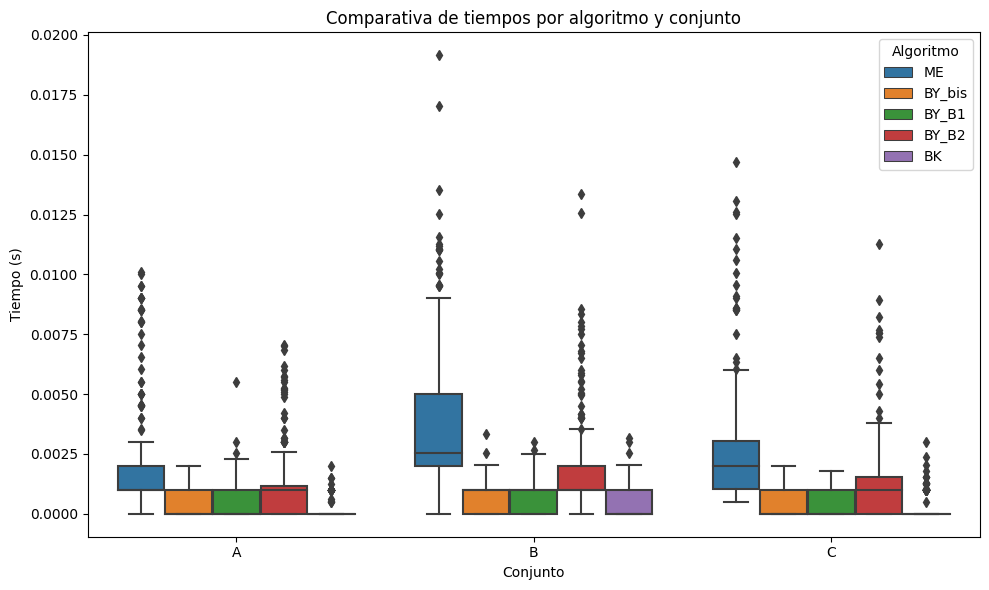

In [10]:
# Boxplot de tiempos
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="conjunto",      # eje X: conjunto A, B, C
    y="tiempo",         # eje Y: tiempo en segundos
    hue="algoritmo"     # color por algoritmo
)
plt.title("Comparativa de tiempos por algoritmo y conjunto")
plt.ylabel("Tiempo (s)")
plt.xlabel("Conjunto")
plt.legend(title="Algoritmo")
plt.tight_layout()
plt.show()

##### Rendimiento en tiempos
* ME presenta tiempos de ejecución más altos y gran dispersión en los conjuntos B y C, reflejando su complejidad al avanzar punteros de forma lineal a través de cada lista.

* BY_bis y BY_B1 son muy eficientes en el conjunto A (intersecciones pequeñas), pero en B y C el coste de las búsquedas binaria o exponencial se hace más patente, incrementando tanto tiempo como variabilidad.

* BK muestra una dispersión temporal reducida y tiempos medianos consistentes en los tres conjuntos, lo que indica estabilidad frente a variaciones en tamaño y número de listas.

#### Boxplot de comparaciones por algoritmo y conjunto

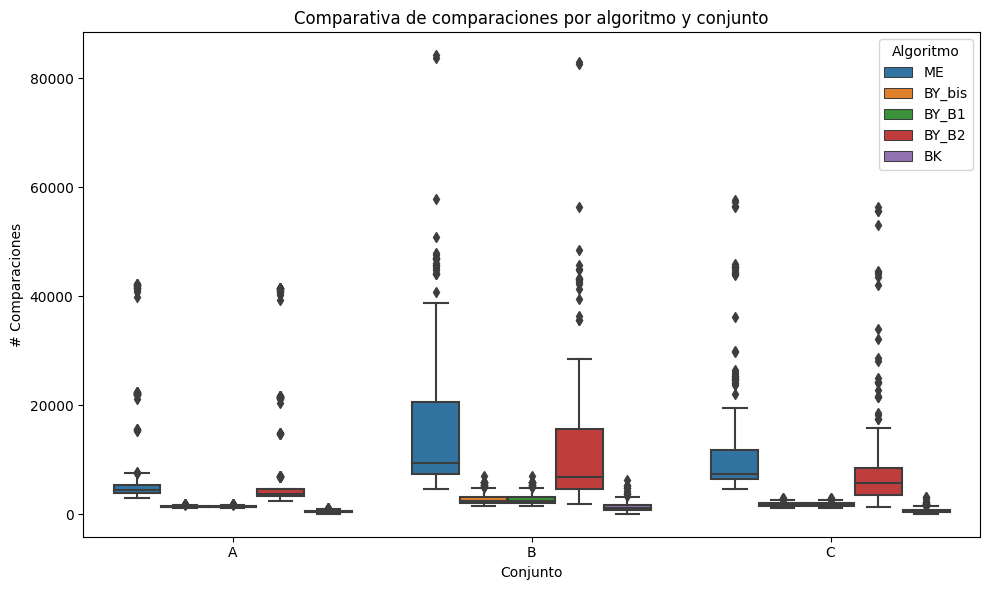

In [11]:
# Boxplot de comparaciones
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="conjunto",
    y="comparaciones",
    hue="algoritmo"
)
plt.title("Comparativa de comparaciones por algoritmo y conjunto")
plt.ylabel("# Comparaciones")
plt.xlabel("Conjunto")
plt.legend(title="Algoritmo")
plt.tight_layout()
plt.show()


##### Comparaciones realizadas
* ME y BY_B2 alcanzan el mayor número de comparaciones en B, ya que ambas estrategias recorren gran parte de los elementos cuando las listas son largas.

+ BY_bis (búsqueda binaria) tiende a generar más comparaciones que BY_B1 en el conjunto C, confirmando que la binaria resulta relativamente costosa cuando el conjunto base es pequeño.

* BK, gracias a los saltos exponenciales, mantiene un conteo moderado y uniforme de comparaciones, sin picos excesivos.

#### Boxplot de longitudes de intersección como control

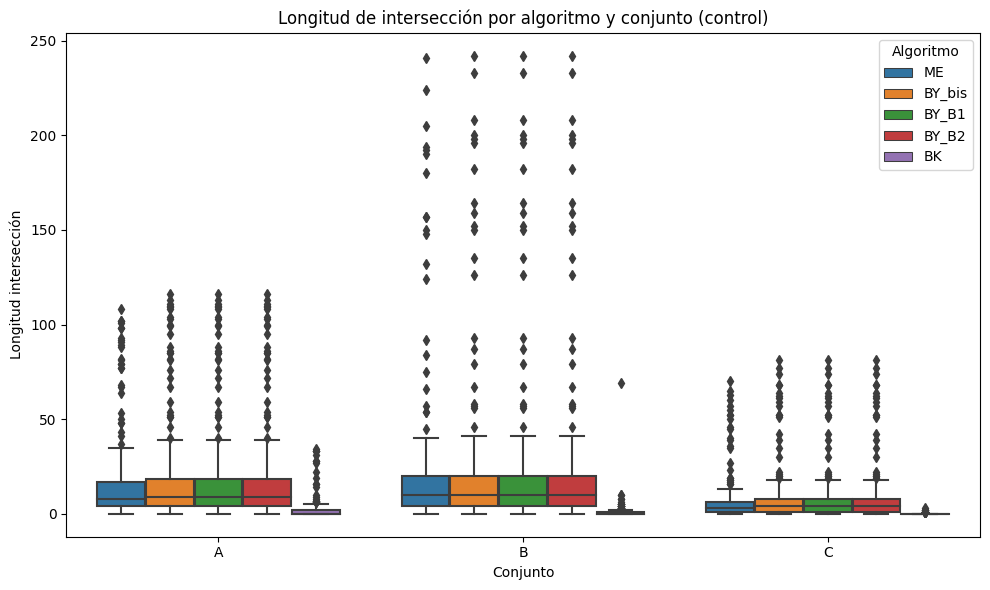

In [12]:
# Boxplot de longitud de intersección
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="conjunto",
    y="long_inter",
    hue="algoritmo"
)
plt.title("Longitud de intersección por algoritmo y conjunto (control)")
plt.ylabel("Longitud intersección")
plt.xlabel("Conjunto")
plt.legend(title="Algoritmo")
plt.tight_layout()
plt.show()


##### Control de longitud de intersección
* Todas las variantes devuelven longitudes de intersección comparables para cada conjunto, validando la corrección de las implementaciones.

* El conjunto C genera intersecciones de tamaño muy reducido en todas las corridas, lo cual explica los bajos tiempos y conteos de comparaciones observados.

* Ahora que hemos recopilado y visualizado nuestros resultados experimentales, vamos a analizar las diferencias de rendimiento entre los algoritmos en los diferentes conjuntos de datos, con sus estadisticas descriptivas

In [13]:
# Agrupar por conjunto y algoritmo y calcular agregados
summary = (
    df
    .groupby(['conjunto', 'algoritmo'])
    .agg(
        tiempo_mediana=('tiempo', 'median'),
        tiempo_media=('tiempo', 'mean'),
        tiempo_min=('tiempo', 'min'),
        tiempo_max=('tiempo', 'max'),
        tiempo_std=('tiempo', 'std'),
        comps_mediana=('comparaciones', 'median'),
        comps_media=('comparaciones', 'mean'),
        comps_min=('comparaciones', 'min'),
        comps_max=('comparaciones', 'max'),
        comps_std=('comparaciones', 'std'),
        long_mediana=('long_inter', 'median'),
        long_media=('long_inter', 'mean'),
        long_min=('long_inter', 'min'),
        long_max=('long_inter', 'max'),
        long_std=('long_inter', 'std')
    )
    .reset_index()
)

# Mostrar tabla de resumen
print("Estadísticas descriptivas por conjunto y algoritmo:")
# Aplicar estilo con formato condicional
styled_summary = (
    summary.style
    .background_gradient(subset=['tiempo_media'], cmap='YlGn')  # verde = mejor (más rápido)
    .background_gradient(subset=['comps_media'], cmap='OrRd')   # rojo = más comparaciones
    .background_gradient(subset=['long_media'], cmap='Blues')   # azul = tamaño intersección
    .set_caption("📊 Estadísticas descriptivas por conjunto y algoritmo")
    .format(precision=2)
)

# Mostrar
styled_summary

Estadísticas descriptivas por conjunto y algoritmo:


,conjunto,algoritmo,tiempo_mediana,tiempo_media,tiempo_min,tiempo_max,tiempo_std,comps_mediana,comps_media,comps_min,comps_max,comps_std,long_mediana,long_media,long_min,long_max,long_std
0,A,BK,0.00,0.00,0.00,0.00,0.00,444.00,492.82,59,1180,191.47,0.00,2.62,0,34,6.62
1,A,BY_B1,0.00,0.00,0.00,0.01,0.00,1352.50,1361.37,1068,1865,164.62,9.00,19.76,0,116,27.82
2,A,BY_B2,0.00,0.00,0.00,0.01,0.00,3695.50,8236.27,2399,41557,10685.38,9.00,19.76,0,116,27.82
3,A,BY_bis,0.00,0.00,0.00,0.00,0.00,1352.50,1361.37,1068,1865,164.62,9.00,19.76,0,116,27.82
4,A,ME,0.00,0.00,0.00,0.01,0.00,4375.00,8933.98,2996,42163,10645.96,8.00,18.14,0,108,25.47
5,B,BK,0.00,0.00,0.00,0.00,0.00,1074.00,1353.94,110,6237,1051.71,0.00,1.15,0,69,5.13
6,B,BY_B1,0.00,0.00,0.00,0.00,0.00,2475.00,2802.26,1407,6998,1157.39,10.00,24.17,0,242,44.64
7,B,BY_B2,0.00,0.00,0.00,0.01,0.00,6881.50,12455.76,1765,82938,13314.15,10.00,24.17,0,242,44.64
8,B,BY_bis,0.00,0.00,0.00,0.00,0.00,2475.00,2802.26,1407,6998,1157.39,10.00,24.17,0,242,44.64
9,B,ME,0.00,0.00,0.00,0.02,0.00,9286.50,16093.73,4650,84172,14022.36,10.00,23.61,0,241,43.62


### 🔍 Análisis de la tabla  
#### ✅ Conjunto A (pares de listas)

**Tiempo de ejecución:**

- BK y las variantes BY_B1/BY_bis presentan una mediana de tiempo de 0 ms, indicando ejecuciones muy rápidas.
- ME y BY_B2 presentan una mediana cercana a 1 ms.
- BY_B2 destaca de las otras, por una media elevada (~1.3 ms) y alta desviación, debido a casos atípicos donde realiza muchas búsquedas.

**Comparaciones:**

- BK requiere pocas comparaciones (mediana ≈ 444), superando a BY_B1/BY_bis (~1 352) y a ME (~4 375).
- BY_B2 eleva considerablemente las comparaciones (mediana ≈ 3 700, media > 8 000) por su estrategia de doble expansión.

**Tamaño de intersección:**

- Las listas en A producen intersecciones pequeñas (mediana entre 0 y 9), lo que favorece a algoritmos como BK, diseñados para abortar rápido cuando hay poca coincidencia.


#### ✅ Conjunto B (intersección de múltiples listas)

**Tiempo de ejecución:**

- BK conserva tiempos muy bajos, incluso al aumentar el número de listas.
- BY_B1 y BY_bis muestran aumentos leves, reflejo de la multiplicación de búsquedas.
- ME y BY_B2 presentan tiempos más altos, particularmente BY_B2 con outliers notables.

**Comparaciones:**

- BK mantiene eficiencia con mediana por debajo de 2 000.
- ME escala mal: más listas implican más comparaciones lineales.
- BY_B1 y BY_bis se mantienen en un rango medio, con BY_B1 ligeramente más eficiente cuando la lista base es pequeña.
- BY_B2 se ve afectado por la acumulación de saltos.

**Tamaño de intersección:**

- Las intersecciones tienen mayor tamaño (5–20 elementos), lo que permite observar cómo se comportan los algoritmos ante cierto solapamiento.


#### ✅ Conjunto C (listas con alta intersección)

**Tiempo de ejecución:**

- BK, BY_B1 y BY_bis mantienen tiempos bajos y consistentes.
- ME mejora respecto a los conjuntos anteriores, aunque su linealidad lo sigue limitando.
- BY_B2 se beneficia parcialmente, pero sus outliers persisten.

**Comparaciones:**

- Todos los algoritmos hacen menos comparaciones por el alto solapamiento.
- BK sigue siendo el más eficiente.
- BY_B1 y BY_bis tienen menos dispersión.
- ME reduce comparaciones, pero sigue siendo el más costoso en promedio.
- BY_B2 mejora, pero sigue siendo inconsistente.

**Tamaño de intersección:**

- Las intersecciones son amplias (medianas de 20 a más de 100 elementos), lo que favorece a algoritmos que aprovechan coincidencias tempranas y bien distribuidas.


### ✅ Conclusiones Generales

Los experimentos muestran diferencias claras entre algoritmos según el tipo y estructura de las listas evaluadas:

- **BK** se perfila como la opción más robusta y estable, manteniendo bajos tiempos de ejecución y comparaciones en todos los escenarios. Su diseño lo vuelve el mejor en cuando se trabaja con conjuntos variados o con intersecciones dispersas.

- **ME** destaca por su sencillez, pero su escalabilidad es limitada. A medida que se incrementa la cantidad o tamaño de las listas, su número de comparaciones y tiempos de ejecución crecen significativamente, haciéndolo poco práctico para conjuntos complejos.

- Las variantes de **Baeza-Yates** ofrecen distintos enfoques:
  - **BY_B1** es eficiente cuando el primer conjunto es pequeño, aprovechando la expansión exponencial para reducir tiempo.
  - **BY_bis** se comporta de forma estable en listas bien equilibradas y con estructuras regulares.
  - **BY_B2**, si bien intenta ser más agresivo, cae frecuentemente en tiempos y comparaciones elevados, especialmente en listas sin buena distribución o estructura.

En contextos reales, podría plantearse una estrategia **híbrida**: aplicar primero BK para filtrar posibles intersecciones rápidas, y luego refinar con una variante de BY si se espera una coincidencia significativa. Esta combinación puede ayudar a balancear robustez y precisión.


### 📋 Tabla comparativa de algoritmos por comportamiento general

| Algoritmo  | Tiempo de ejecución     | Comparaciones           | Estabilidad | Escenarios favorables |
|------------|--------------------------|--------------------------|-------------|------------------------|
| **BK**     | Muy bajo (≈ 0 ms)        | Muy bajo (≈ 400–2 000)   | Alta        | Listas con baja o alta intersección; robusto ante cambios en tamaño o estructura. |
| **ME**     | Medio (≈ 1 ms)           | Alto (≈ 4 000+)          | Baja        | Casos simples o enseñanza; no recomendado para listas grandes o numerosas. |
| **BY_B1**  | Muy bajo (≈ 0 ms)        | Medio-bajo (≈ 1 300)     | Media       | Eficiente con primer conjunto pequeño; adaptable en estructuras dispersas. |
| **BY_bis** | Muy bajo (≈ 0 ms)        | Medio (≈ 1 400)          | Alta        | Buen rendimiento en listas balanceadas y con buena estructura. |
| **BY_B2**  | Variable (media elevada) | Muy alto (> 8 000)       | Baja        | Escenarios con intersección lejana o tardía; sensible a la distribución. |


## 📚 Referencias
Baeza-Yates, R. (2004). *A fast set intersection algorithm for sorted sequences*. In *Combinatorial Pattern Matching*. Springer.

Cormen, Thomas H, Charles E Leiserson, Ronald L Rivest, y Clifford Stein. 2022. Introduction to Algorithms. MIT Press.

Estivill-Castro, Vladmir, y Derick Wood. 1992. "A survey of adaptive sorting algorithms." ACM Computing Surveys (CSUR) 24 (4): 441–76.
